In [6]:
# importeer de benodigde packages.
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import root_mean_squared_error 

data_test = pd.read_csv('data_test.csv')


In [2]:
# we openen het model.
with open('beslisboom.pkl', 'rb') as file:
    model = pickle.load(file)

In [3]:
# Definieer X_test en y_test.

X_test= data_test.drop(columns = ['Churn'])
y_test= data_test['Churn']



In [4]:
# voorspel de kansen en plaats ze in een dataframe om ze te bekijken.
y_pred = model.predict_proba(X_test)


pd.DataFrame(y_pred)

,0,1
0,0.881443,0.118557
1,0.881443,0.118557
2,0.980178,0.019822
3,0.980178,0.019822
4,0.881443,0.118557
...,...,...
850,0.980178,0.019822
851,0.980178,0.019822
852,0.980178,0.019822
853,0.524444,0.475556


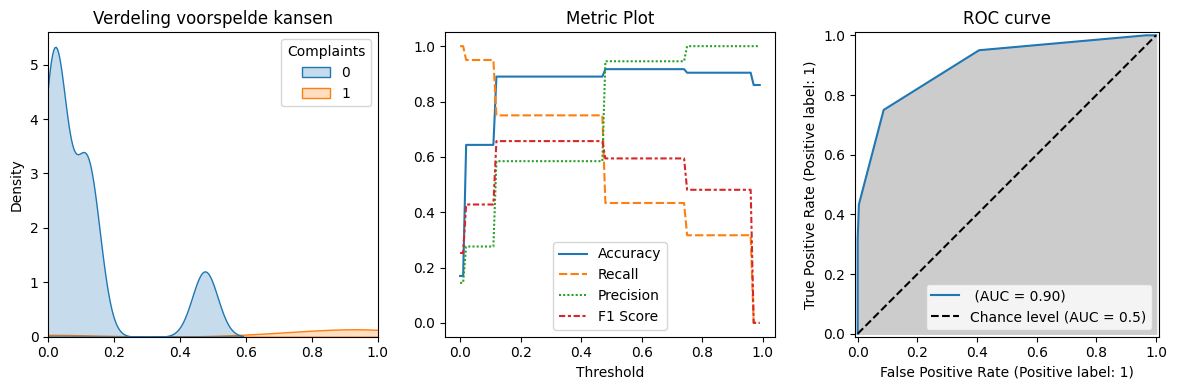

In [5]:
# In deze  cel worden 3  plots gemaakt de verdeling van de kansen, een metric plot en roc curve.

# Functie die een classificatie report omzet in rijen van een dataframe.
def make_row(cr):
    return {
        'Accuracy':  cr['accuracy'],
        'Recall':    cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 Score':  cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        y_test, 
        y_pred[:,1] > t, 
        zero_division=True, 
        output_dict=True)) for t in thresholds])
plot_data.index = thresholds


plt.figure(figsize=(12,4), layout='tight')

# Plot 1 : Verdeling van de kansen
plt.subplot(1,3,1)
sns.kdeplot(data_test, x = y_pred[:,1], hue = 'Complaints',fill = True)
plt.xlim(0,1)
plt.title('Verdeling voorspelde kansen')

# Plot 2 : Een metric plot
nul_acc = []
plt.subplot(1,3,2)
sns.lineplot(plot_data)
plt.plot([0,1], [nul_acc, nul_acc], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')


# Plot 3 : Een ROC curve/
ax = plt.subplot(1,3,3)
roc = RocCurveDisplay.from_predictions(
    y_test, 
    y_pred[:,1], 
     
    name = '', 
    plot_chance_level = True,
    ax=ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()